In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_import = pd.read_csv("./data/housing.csv")`

In [8]:
data_clean

,beds,baths,size,price
0,3,2.5,2590.0,795000.0
1,4,2.0,2240.0,915000.0
2,4,3.0,2040.0,950000.0
3,4,3.0,3800.0,1950000.0
4,2,2.0,1042.0,950000.0
...,...,...,...,...
2011,3,2.0,1370.0,910000.0
2012,1,1.0,889.0,550000.0
2013,4,2.0,2140.0,1150000.0
2014,2,2.0,795.0,590000.0


In [5]:
data_clean = data_import.drop(columns=["Unnamed: 0", "zip_code"])

In [85]:
def compute_gradient(x_train, y_train, w, b, lamba):
    m,n = x_train.shape
    dj_dw = np.zeros(n).ravel()
    dj_db = 0

    # print(f"lamba{(lamba/m)*w}")

    
    pred = (x_train@w+b)
    error = pred - y_train
    dj_dw += error @ x_train/m
    dj_db += np.sum(error)/m
    print(dj_dw)

    dj_dw += (lamba/m) * w

    return dj_dw, dj_db

In [91]:
def run_gradient(x_train, y_train, alpha, epochs, lamba):
    m, n = x_train.shape
    w = np.zeros(n)
    b = 0

    for i in range(epochs):
        dw, db = compute_gradient(x_train, y_train, w, b, lamba)

        w = w - alpha * dw
        b = b - alpha * db

        # if i%20 == 0:
        #     print(f"weight:{w}, bais:{b}")

    return w, b

In [92]:
def z_score_normalization(data):
    mean_ = np.mean(data, axis=0)
    std_ = np.std(data, axis=0)

    return (data-mean_)/std_

In [93]:
norm = z_score_normalization(np.array(data_clean))
norm

array([[ 0.11345495,  0.33942758,  0.9286394 , -0.17865468],
       [ 0.91040676, -0.15968693,  0.54816506, -0.05151734],
       [ 0.91040676,  0.83854209,  0.33075115, -0.01443562],
       ...,
       [ 0.91040676, -0.15968693,  0.4394581 ,  0.19745993],
       [-0.68349687, -0.15968693, -1.02265042, -0.39584762],
       [ 0.11345495, -0.15968693, -0.0279818 , -0.32274365]],
      shape=(2016, 4))

In [94]:
x_train, y_train = norm[:, 0:-1], norm[:, -1].ravel()
print(x_train.shape, y_train.shape)

(2016, 3) (2016,)


In [95]:
w, b = run_gradient(x_train, y_train, 0.1, 1000, 1)

[-0.29351562 -0.31732464 -0.44414027]
[-0.20916297 -0.23677669 -0.3558826 ]
[-0.14532123 -0.17568708 -0.28834432]
[-0.09706856 -0.12938661 -0.23657002]
[-0.06066289 -0.09432541 -0.19679176]
[-0.03325917 -0.06780465 -0.16614443]
[-0.01269435 -0.04777251 -0.14244939]
[ 0.00267607 -0.03266917 -0.12404995]
[ 0.01410236 -0.02130883 -0.10968623]
[ 0.02253501 -0.01279005 -0.09840011]
[ 0.02869662 -0.00642763 -0.08946286]
[ 0.0331365  -0.00170072 -0.08232019]
[ 0.03627221  0.00178652 -0.07655047]
[ 0.03842115  0.00433492 -0.07183289]
[ 0.03982455  0.0061731  -0.06792333]
[ 0.04066574  0.00747472 -0.06463598]
[ 0.04108404  0.00837171 -0.06182937]
[ 0.04118527  0.00896427 -0.05939573]
[ 0.04104983  0.00932845 -0.05725295]
[ 0.04073876  0.00952197 -0.05533842]
[ 0.04029839  0.00958862 -0.05360435]
[ 0.03976387  0.00956157 -0.05201422]
[ 0.03916185  0.00946596 -0.05054012]
[ 0.03851251  0.00932079 -0.04916065]
[ 0.03783113  0.00914045 -0.04785937]
[ 0.03712925  0.00893575 -0.04662365]
[ 0.03641556

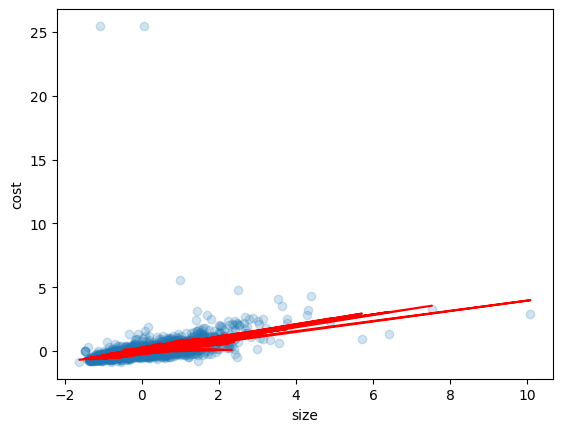

In [77]:
plt.scatter(x_train[:, -1], y_train, alpha=0.2)
plt.plot(x_train[:, -1], x_train@w+b, color="red")
plt.xlabel("size")
plt.ylabel("cost")
plt.show()

In [74]:
x_plot = np.linspace(np.min(x_train[:, -1]), np.max(x_train[:, -1]), 100)

In [79]:
a = x_train@w+b

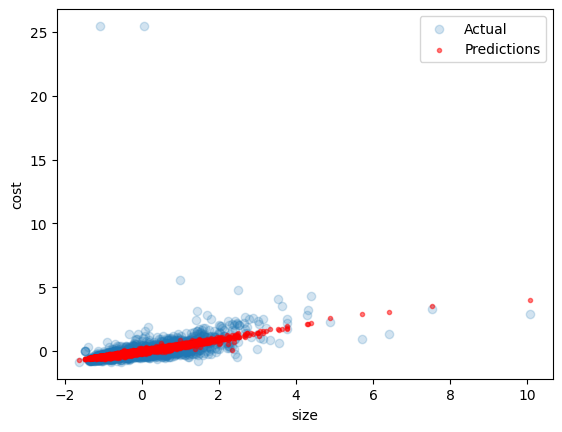

In [84]:
plt.scatter(x_train[:, -1], y_train, alpha=0.2, label="Actual")
plt.scatter(x_train[:, -1], x_train @ w + b, color="red", alpha=0.5, marker='.', label="Predictions")

plt.xlabel("size")
plt.ylabel("cost")
plt.legend()
plt.show()